In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.arima.model import ARIMA



---
# Aperçu de Yt

In [3]:
#import des données

data=pd.read_csv("velib_horaire.csv")
data["Departure_Time"]= pd.to_datetime(data["Departure_Time"])
data = data.sort_values("Departure_Time").set_index("Departure_Time")

print(data.head())


                     duree_moyenne_sec  proportion_velos_electriques  \
Departure_Time                                                         
2024-05-01 00:00:00        1066.162766                      0.588298   
2024-05-01 01:00:00        1190.689723                      0.570299   
2024-05-01 02:00:00        1186.409469                      0.543506   
2024-05-01 03:00:00        1172.889674                      0.562500   
2024-05-01 04:00:00        1112.989264                      0.565184   

                     nombre_trajets  
Departure_Time                       
2024-05-01 00:00:00            4700  
2024-05-01 01:00:00            3542  
2024-05-01 02:00:00            3126  
2024-05-01 03:00:00            1840  
2024-05-01 04:00:00            1304  


In [4]:
# extration du processus stationnaire à étudier
Y=data["nombre_trajets"]

#statistiques descriptives
print("Moyenne :", Y.mean())
print("Variance :", Y.var())
print("Écart-type :", Y.std())

Moyenne : 6016.092361111111
Variance : 17630569.02898957
Écart-type : 4198.877115252311


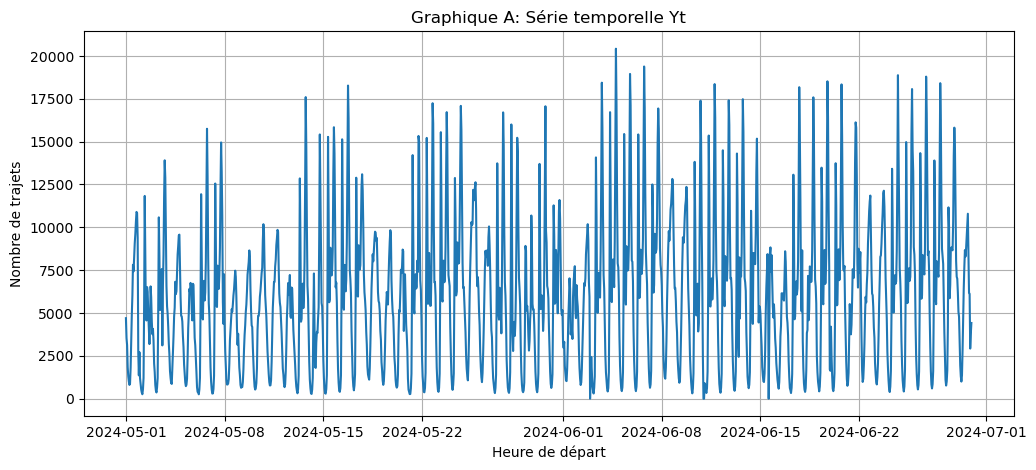

In [5]:

plt.figure(figsize=(12, 5))
plt.plot(Y)
plt.title("Graphique A: Série temporelle Yt")
plt.xlabel("Heure de départ")
plt.ylabel("Nombre de trajets")
plt.grid(True)
plt.show()

---

# Recherche d'une tendance polynomiale

In [6]:
# test d'une tendance polynomiale de degré 2
t = np.arange(len(Y))
X = sm.add_constant(np.column_stack([t, t**2]))
mod = sm.OLS(Y.values, X).fit()
print(mod.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     16.02
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           1.31e-07
Time:                        18:10:13   Log-Likelihood:                -14040.
No. Observations:                1440   AIC:                         2.809e+04
Df Residuals:                    1437   BIC:                         2.810e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4643.9467    328.082     14.155      0.0

- la tendance quadratique n’est pas retenue car $t^2$ a une p-value de 0.177, donc non significative.
- la tendance linéaire est significative car $t$ a une p-value de 0.007, mais R-squared=0.022, donc elle explique seulement 2.2 % de la variabilité.

In [7]:
# retrait de la tendance polynomiamle de degrès 1

X = sm.add_constant(t)
mod_lin = sm.OLS(Y.values, X).fit()
y_sans_tendance = Y - mod_lin.fittedvalues

---

# Recherche de saisonnalité

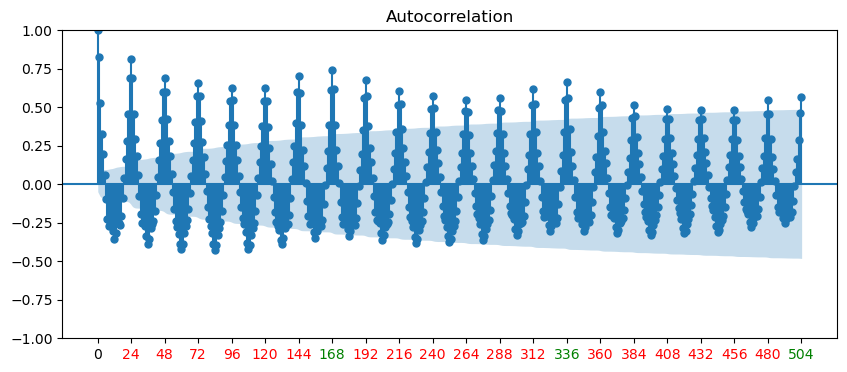

In [ ]:

fig, ax = plt.subplots(figsize=(10,4))
plot_acf(Y, lags=24*21, ax=ax) #fonction d'autocorrélation de Y

# graduations : tous les multiples de 24
xticks = np.arange(0, 24*21 + 1, 24)
ax.set_xticks(xticks)

# forcer l'affichage avant de modifier les couleurs
plt.draw()

# couleur des labels
for tick, val in zip(ax.get_xticklabels(), xticks):
    if val % 168 == 0 and val != 0:
        tick.set_color("green")
    elif val % 24 == 0 and val != 0:
        tick.set_color("red")

plt.show()

On observe une saisonnalité journalière (indices rouges) et hebdomadaire (inidece vert) .

In [9]:
# retrait de la saisonnalité

Y_diff = y_sans_tendance.diff(24).diff(168).dropna()

---

# Etude plus détaillée de la saisonnalité

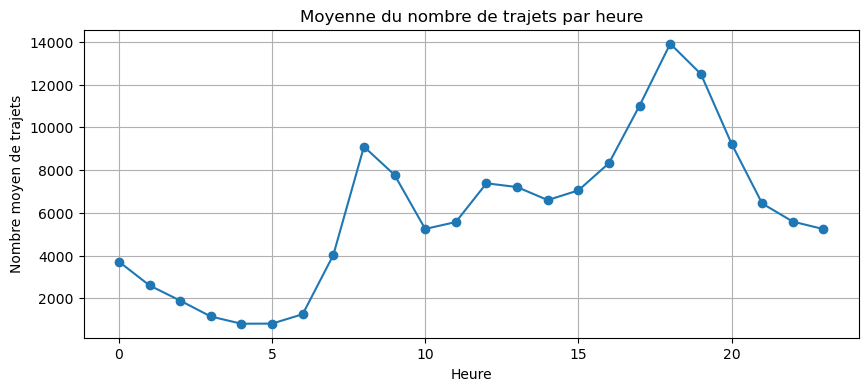

In [10]:
profil_horaire = Y.groupby(Y.index.hour).mean()

plt.figure(figsize=(10,4))
plt.plot(profil_horaire.index, profil_horaire.values, marker="o")
plt.title("Moyenne du nombre de trajets par heure")
plt.xlabel("Heure")
plt.ylabel("Nombre moyen de trajets")
plt.grid(True)
plt.show()

On observe une dépendance à l'heure de la journée: heure de pointe matin et soir

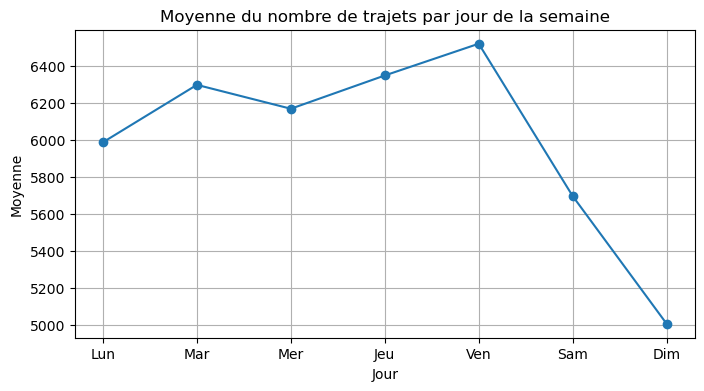

In [11]:
jours = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]
profil_semaine = Y.groupby(Y.index.dayofweek).mean()

plt.figure(figsize=(8,4))
plt.plot(jours, profil_semaine.values, marker="o")
plt.title("Moyenne du nombre de trajets par jour de la semaine")
plt.xlabel("Jour")
plt.ylabel("Moyenne")
plt.grid(True)
plt.show()

On observe une dépendance importante au jour de la semaine: baisse importante le weekend

---

# Vérification finale de la stationnarité

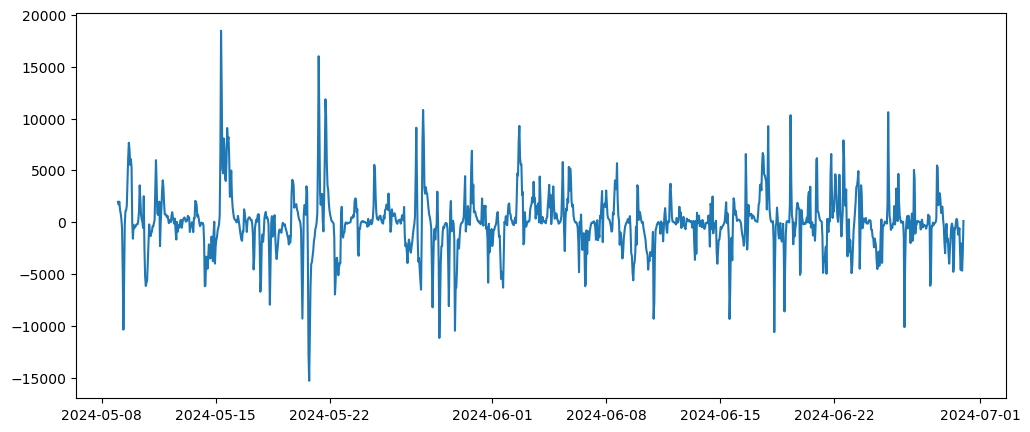

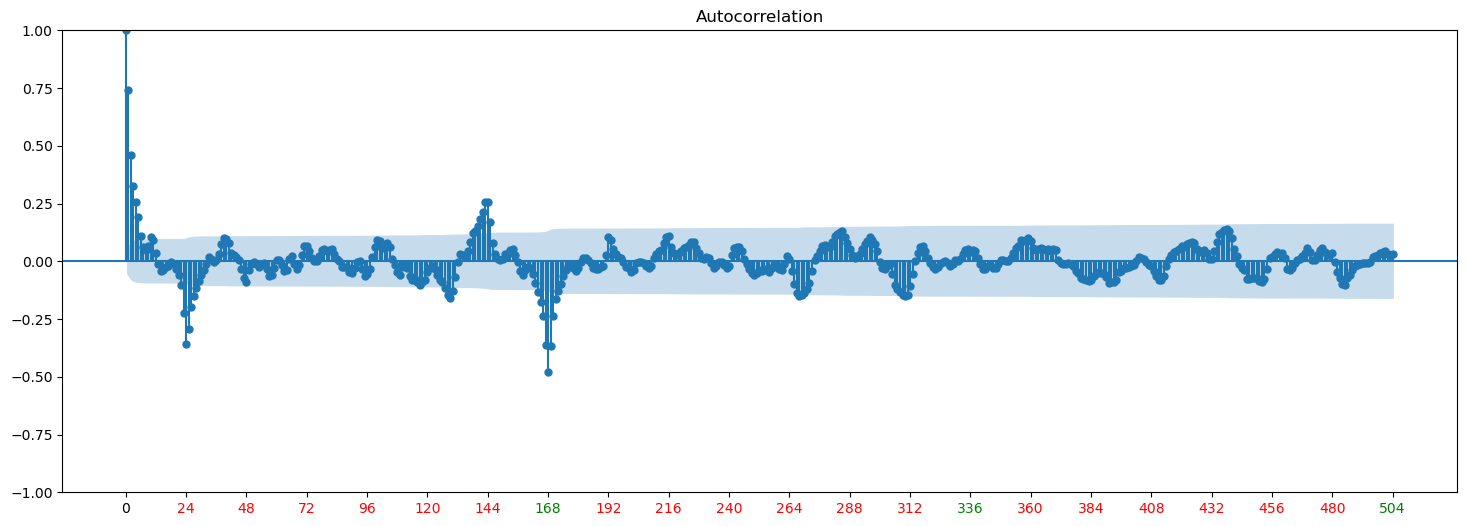

In [14]:

plt.figure(figsize=(12, 5))
plt.plot(Y_diff)

fig, ax = plt.subplots(figsize=(18, 6))
plot_acf(Y_diff, lags=24*21,ax=ax)

# graduations : tous les multiples de 24
xticks = np.arange(0, 24*21 + 1, 24)
ax.set_xticks(xticks)

# forcer l'affichage avant de modifier les couleurs
plt.draw()

# couleur des labels
for tick, val in zip(ax.get_xticklabels(), xticks):
    if val % 168 == 0 and val != 0:
        tick.set_color("green")
    elif val % 24 == 0 and val != 0:
        tick.set_color("red")
plt.show()

La nouvelle série semble à présent stationnaire


---

### Ajustement d'un modèle ARMA